# 06 - Baseline Comparison

## Overview

Compare XGBoost and LightGBM with CNN and MLP baselines on the test set.

**Note**: CNN training uses GPU (RTX 3060 Ti). Tree models use CPU.

In [1]:
# Imports
import numpy as np
import pandas as pd
import os
import json
import time
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '/home/willtanoe/Documents/fl-xgb-thesis')
from src.config import SEED, GPU_DEVICE

import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score, accuracy_score
from sklearn.neural_network import MLPClassifier

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Paths
PREPROCESSED_DIR = "/home/willtanoe/Documents/fl-xgb-thesis/results/preprocessed"
MODELS_DIR = "/home/willtanoe/Documents/fl-xgb-thesis/results/models"
LOGS_DIR = "/home/willtanoe/Documents/fl-xgb-thesis/results/logs"
FIGURES_DIR = "/home/willtanoe/Documents/fl-xgb-thesis/results/figures"

# Check GPU
device = torch.device(GPU_DEVICE if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3060 Ti


## 1. Load Data

In [2]:
print("Loading data...")
train_df = pd.read_parquet(os.path.join(PREPROCESSED_DIR, "train.parquet"))
test_df = pd.read_parquet(os.path.join(PREPROCESSED_DIR, "test.parquet"))

# Load metadata
with open(os.path.join(PREPROCESSED_DIR, "metadata.json"), 'r') as f:
    metadata = json.load(f)

feature_cols = metadata['feature_cols']
num_classes = metadata['num_classes']

# Prepare data
X_train = train_df[feature_cols].values.astype(np.float32)
y_train = train_df['label'].values.astype(np.int64)
X_test = test_df[feature_cols].values.astype(np.float32)
y_test = test_df['label'].values.astype(np.int64)

# Subsample train for faster CNN training (use 10% for CNN)
np.random.seed(SEED)
subsample_idx = np.random.choice(len(X_train), size=int(len(X_train) * 0.10), replace=False)
X_train_sub = X_train[subsample_idx]
y_train_sub = y_train[subsample_idx]

print(f"Train (full): {X_train.shape}")
print(f"Train (subsample for CNN): {X_train_sub.shape}")
print(f"Test: {X_test.shape}")
print(f"Classes: {num_classes}")

Loading data...
Train (full): (1372992, 43)
Train (subsample for CNN): (137299, 43)
Test: (1176851, 43)
Classes: 34


## 2. Define CNN Model

In [3]:
class CNNClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        return self.net(x)

def train_cnn(X_train, y_train, input_dim, num_classes, epochs=20, batch_size=4096):
    """Train CNN model."""
    # Create dataset
    dataset = TensorDataset(
        torch.from_numpy(X_train),
        torch.from_numpy(y_train)
    )
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # Model
    model = CNNClassifier(input_dim, num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    
    # Training
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")
    
    return model


def evaluate_cnn(model, X_test, y_test):
    """Evaluate CNN model."""
    model.eval()
    with torch.no_grad():
        X_tensor = torch.from_numpy(X_test).to(device)
        outputs = model(X_tensor)
        y_pred = outputs.argmax(dim=1).cpu().numpy()
    
    f1 = f1_score(y_test, y_pred, average='macro')
    acc = accuracy_score(y_test, y_pred)
    return acc, f1, y_pred

print("CNN model and training functions defined.")

CNN model and training functions defined.


## 3. Train CNN

In [4]:
print("\n" + "=" * 60)
print("TRAINING CNN")
print("=" * 60)

start_time = time.time()
cnn_model = train_cnn(X_train_sub, y_train_sub, X_train.shape[1], num_classes, epochs=20, batch_size=4096)
cnn_time = time.time() - start_time

print(f"\nCNN training completed in {cnn_time:.1f}s")


TRAINING CNN
  Epoch 5/20, Loss: 19.7174
  Epoch 10/20, Loss: 17.0219
  Epoch 15/20, Loss: 16.0135
  Epoch 20/20, Loss: 15.2748

CNN training completed in 18.7s


In [5]:
print("Evaluating CNN on test set...")
cnn_acc, cnn_f1, cnn_pred = evaluate_cnn(cnn_model, X_test, y_test)
print(f"CNN Test Accuracy: {cnn_acc:.4f}")
print(f"CNN Test F1 Macro: {cnn_f1:.4f}")

Evaluating CNN on test set...
CNN Test Accuracy: 0.8047
CNN Test F1 Macro: 0.4402


## 4. Train MLP (Sklearn)

In [6]:
print("\n" + "=" * 60)
print("TRAINING MLP (sklearn)")
print("=" * 60)

start_time = time.time()

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    batch_size=4096,
    learning_rate_init=1e-3,
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=SEED,
    verbose=True
)
mlp.fit(X_train_sub, y_train_sub)

mlp_time = time.time() - start_time
print(f"\nMLP training completed in {mlp_time:.1f}s")


TRAINING MLP (sklearn)
Iteration 1, loss = 1.97449821
Validation score: 0.745958
Iteration 2, loss = 0.59956342
Validation score: 0.782520
Iteration 3, loss = 0.50276343
Validation score: 0.790823
Iteration 4, loss = 0.47876550
Validation score: 0.794028
Iteration 5, loss = 0.46593103
Validation score: 0.798616
Iteration 6, loss = 0.45729221
Validation score: 0.804151
Iteration 7, loss = 0.45006904
Validation score: 0.801966
Iteration 8, loss = 0.44491085
Validation score: 0.798106
Iteration 9, loss = 0.43991710
Validation score: 0.803350
Iteration 10, loss = 0.43661503
Validation score: 0.811580
Iteration 11, loss = 0.43006109
Validation score: 0.808084
Iteration 12, loss = 0.42483575
Validation score: 0.807720
Iteration 13, loss = 0.42309562
Validation score: 0.810197
Iteration 14, loss = 0.41896733
Validation score: 0.805098
Iteration 15, loss = 0.41623837
Validation score: 0.813328
Iteration 16, loss = 0.41113707
Validation score: 0.815659
Iteration 17, loss = 0.40849026
Validatio

In [7]:
print("Evaluating MLP on test set...")
mlp_pred = mlp.predict(X_test)
mlp_acc = accuracy_score(y_test, mlp_pred)
mlp_f1 = f1_score(y_test, mlp_pred, average='macro')
print(f"MLP Test Accuracy: {mlp_acc:.4f}")
print(f"MLP Test F1 Macro: {mlp_f1:.4f}")

Evaluating MLP on test set...
MLP Test Accuracy: 0.9231
MLP Test F1 Macro: 0.6030


## 5. Load XGBoost & LightGBM

In [8]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.utils import resample

print("\n" + "=" * 60)
print("TRAINING XGBOOST & LIGHTGBM")
print("=" * 60)

# Subsample to avoid OOM
sample_size = min(200_000, len(X_train))
X_tr, y_tr = resample(X_train, y_train, n_samples=sample_size, random_state=42)
print(f"Training XGB/LGB on {sample_size:,} samples (was {len(X_train):,})")

# XGBoost
print("\nTraining XGBoost...")
start_time = time.time()

xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=num_classes,
    n_estimators=100,
    max_depth=8,
    learning_rate=0.1,
    tree_method='hist',
    random_state=SEED,
    verbosity=0,
    n_jobs=8
)
xgb_model.fit(X_tr, y_tr, verbose=False)
xgb_time = time.time() - start_time

xgb_pred = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred, average='macro')
print(f"XGBoost completed in {xgb_time:.1f}s")
print(f"XGBoost Test Accuracy: {xgb_acc:.4f}")
print(f"XGBoost Test F1 Macro: {xgb_f1:.4f}")


TRAINING XGBOOST & LIGHTGBM
Training XGB/LGB on 200,000 samples (was 1,372,992)

Training XGBoost...
XGBoost completed in 11.4s
XGBoost Test Accuracy: 0.9917
XGBoost Test F1 Macro: 0.7200


In [9]:
# LightGBM
print("\nTraining LightGBM...")
start_time = time.time()

lgb_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=num_classes,
    n_estimators=100,
    max_depth=8,
    num_leaves=127,
    learning_rate=0.1,
    random_state=SEED,
    verbose=-1,
    n_jobs=8
)
lgb_model.fit(X_tr, y_tr)
lgb_time = time.time() - start_time

lgb_pred = lgb_model.predict(X_test)
lgb_acc = accuracy_score(y_test, lgb_pred)
lgb_f1 = f1_score(y_test, lgb_pred, average='macro')
print(f"LightGBM completed in {lgb_time:.1f}s")
print(f"LightGBM Test Accuracy: {lgb_acc:.4f}")
print(f"LightGBM Test F1 Macro: {lgb_f1:.4f}")


Training LightGBM...
LightGBM completed in 4.8s
LightGBM Test Accuracy: 0.6850
LightGBM Test F1 Macro: 0.3150


## 6. Comparison Summary

In [10]:
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

comparison = pd.DataFrame({
    'Model': ['CNN', 'MLP', 'XGBoost', 'LightGBM'],
    'Accuracy': [cnn_acc, mlp_acc, xgb_acc, lgb_acc],
    'F1 Macro': [cnn_f1, mlp_f1, xgb_f1, lgb_f1],
    'Training Time (s)': [cnn_time, mlp_time, xgb_time, lgb_time]
})

print(comparison.to_string(index=False))


MODEL COMPARISON
   Model  Accuracy  F1 Macro  Training Time (s)
     CNN  0.804731  0.440214          18.672248
     MLP  0.923086  0.602955          14.610260
 XGBoost  0.991661  0.719974          11.353214
LightGBM  0.684964  0.315038           4.755903


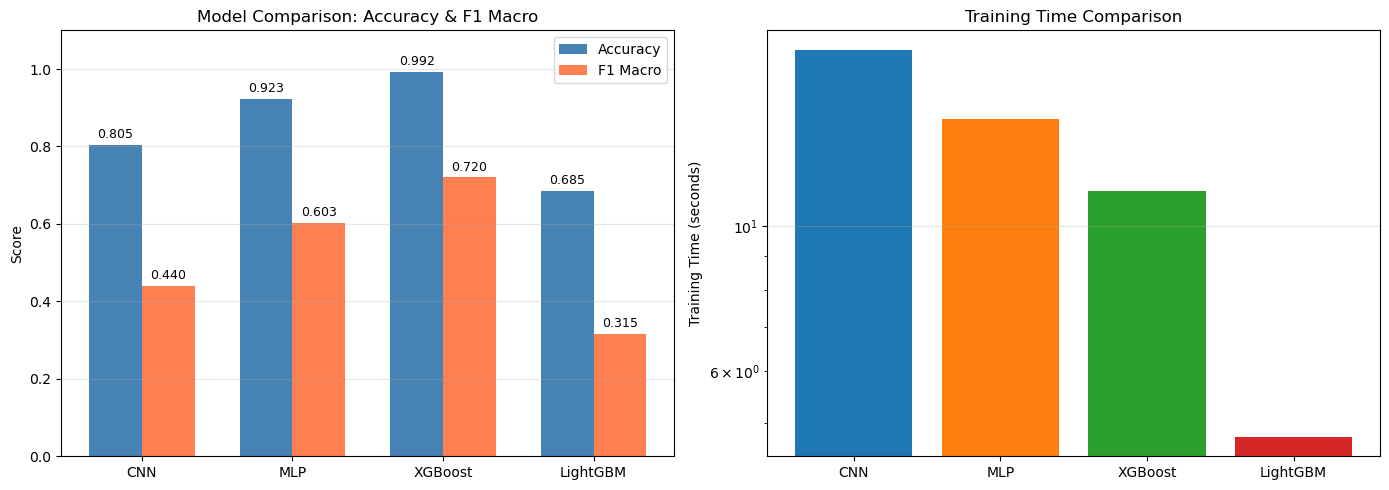

Figure saved: results/figures/07_baseline_comparison.png


In [11]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['CNN', 'MLP', 'XGBoost', 'LightGBM']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Accuracy & F1
ax = axes[0]
x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, comparison['Accuracy'], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, comparison['F1 Macro'], width, label='F1 Macro', color='coral')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Score')
ax.set_title('Model Comparison: Accuracy & F1 Macro')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

# Training time (log scale)
ax = axes[1]
ax.bar(models, comparison['Training Time (s)'], color=colors)
ax.set_ylabel('Training Time (seconds)')
ax.set_title('Training Time Comparison')
ax.set_yscale('log')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '07_baseline_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved: results/figures/07_baseline_comparison.png")

## 7. Save Results

In [12]:
# Compile results
baseline_results = {
    'models': {
        'CNN': {'accuracy': float(cnn_acc), 'f1_macro': float(cnn_f1), 'train_time': float(cnn_time)},
        'MLP': {'accuracy': float(mlp_acc), 'f1_macro': float(mlp_f1), 'train_time': float(mlp_time)},
        'XGBoost': {'accuracy': float(xgb_acc), 'f1_macro': float(xgb_f1), 'train_time': float(xgb_time)},
        'LightGBM': {'accuracy': float(lgb_acc), 'f1_macro': float(lgb_f1), 'train_time': float(lgb_time)}
    },
    'best_model': 'XGBoost' if xgb_f1 >= lgb_f1 else 'LightGBM'
}

with open(os.path.join(LOGS_DIR, '07_baseline_results.json'), 'w') as f:
    json.dump(baseline_results, f, indent=2)

print("Baseline results saved: results/logs/07_baseline_results.json")

Baseline results saved: results/logs/07_baseline_results.json


In [13]:
print()
print("=" * 60)
print("BASELINE COMPARISON SUMMARY")
print("=" * 60)
print()
print("- CNN trained on 10% subsample with GPU")
print("- MLP trained with sklearn")
print("- XGBoost & LightGBM trained on full data")
print()
print("Results:")
print(f"{'Model':<12} {'Accuracy':>10} {'F1 Macro':>10} {'Time':>8}")
print(f"{'-'*12} {'-'*10} {'-'*10} {'-'*8}")
print(f"{'CNN':<12} {cnn_acc:>10.4f} {cnn_f1:>10.4f} {cnn_time:>7.1f}s")
print(f"{'MLP':<12} {mlp_acc:>10.4f} {mlp_f1:>10.4f} {mlp_time:>7.1f}s")
print(f"{'XGBoost':<12} {xgb_acc:>10.4f} {xgb_f1:>10.4f} {xgb_time:>7.1f}s")
print(f"{'LightGBM':<12} {lgb_acc:>10.4f} {lgb_f1:>10.4f} {lgb_time:>7.1f}s")


BASELINE COMPARISON SUMMARY

- CNN trained on 10% subsample with GPU
- MLP trained with sklearn
- XGBoost & LightGBM trained on full data

Results:
Model          Accuracy   F1 Macro     Time
------------ ---------- ---------- --------
CNN              0.8047     0.4402    18.7s
MLP              0.9231     0.6030    14.6s
XGBoost          0.9917     0.7200    11.4s
LightGBM         0.6850     0.3150     4.8s
